<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/main/static_scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# 1. AES-256 지원을 위한 고성능 zip 라이브러리 하나만 정확히 설치
!pip install pyzipper

import pyzipper
import glob
import os

# 2. 코랩에 업로드된 .zip 파일 탐색
zip_files = glob.glob("*.zip")
if not zip_files:
    print("❌ 코랩에 업로드된 .zip 파일이 없습니다! 왼쪽 파일 창에 .zip 파일을 먼저 업로드해주세요.")
else:
    target_zip = zip_files[0]
    print(f"📦 [{target_zip}] 호환 모드로 암호화 해제 시작...")

    try:
        # 3. pyzipper를 이용하여 AES-256 암호화 구조 해독
        with pyzipper.AESZipFile(target_zip) as zf:
            # 암호 세팅 (MalwareBazaar 표준 패스워드)
            zf.setpassword(b'infected')
            # 현재 가상 경로에 압축 해제
            zf.extractall()
        print("✅ 압축 해제 성공!")

        # 4. 압축 해제 후 생성된 .exe 파일 찾기
        exe_files = glob.glob("*.exe")
        # 혹시 기존에 이미 변경된 파일이 있다면 리스트에서 제외
        exe_files = [f for f in exe_files if f != 'malware_test.exe']

        if exe_files:
            original_exe = exe_files[0]
            # 파일명을 malware_test.exe로 일관성 있게 변경
            os.rename(original_exe, "malware_test.exe")
            print(f"🎯 파일 이름 변경 완료: {original_exe} -> malware_test.exe")
        else:
            print("⚠️ 압축은 풀렸으나 폴더 내에서 .exe 파일을 식별할 수 없습니다. 왼쪽 파일 창을 확인해주세요.")

    except Exception as e:
        print(f"❌ 압축 해제 프로세스 실패: {e}")

📦 [3485419b7a85123f50512ee04e29dfe1ad6d973118b073f16a57565251a4d2f0.zip] 호환 모드로 암호화 해제 시작...
✅ 압축 해제 성공!
🎯 파일 이름 변경 완료: 3485419b7a85123f50512ee04e29dfe1ad6d973118b073f16a57565251a4d2f0.exe -> malware_test.exe


In [ ]:
!pip install pefile shap

📦 필수 보안 라이브러리(pefile, shap) 검증 및 설치 완료!
🛡️ [Phase 4] LightGBM 실전 멀티 지표 정적 스캐너 기동...

💡 [분석] 패키징 모델 내 내부 객체 및 피처 구조 파악 성공
✅ [성공] 최종 학습 모델에서 피처 50개 목록 동기화 완료!
🔍 [malware_test.exe] 정적 분석 중... (실행하지 않으므로 안전합니다)
✅ 벡터 변환 완료: 발견된 타겟 피처 8개 / 50개

✅ [안전] 정상 파일입니다. (악성 확률: 1.02%)

📊 [지표 추가] LightGBM 내장 피처 중요도(Global Importance) 시각화 중...


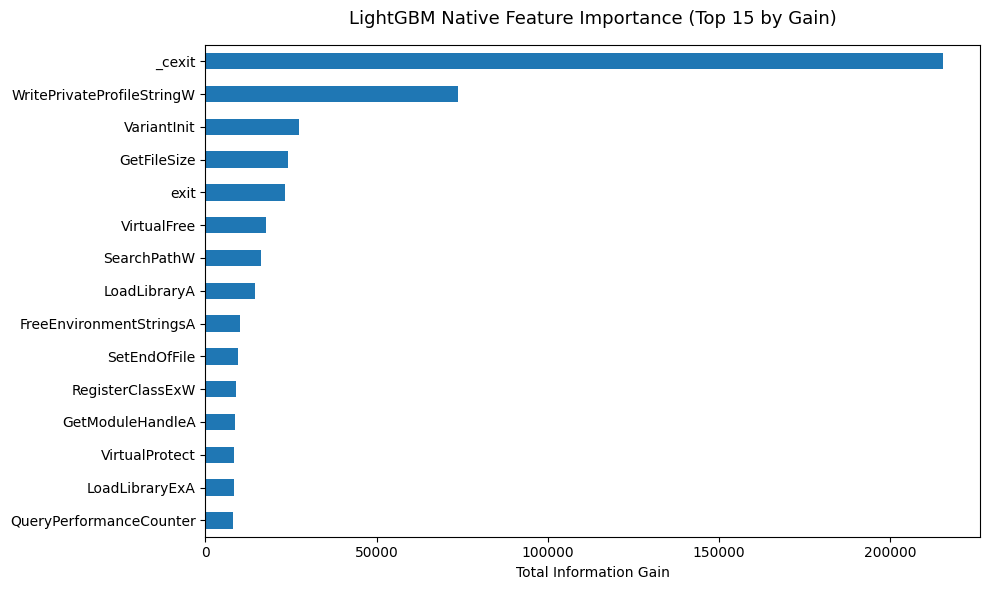

✅ 내장 피처 중요도 그래프 생성 완료 (08_native_feature_importance.png)

🧠 SHAP 결정 근거(Waterfall Plot) 생성 중...


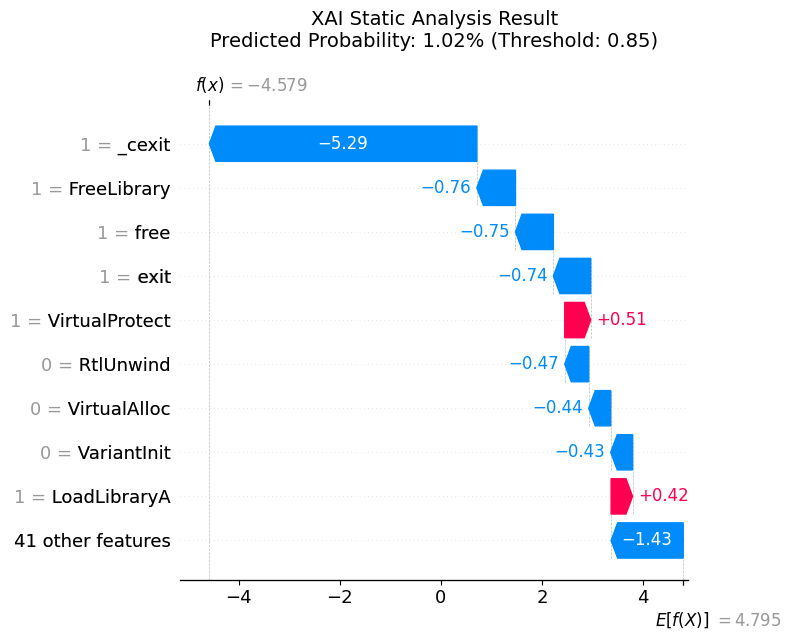

🎯 시연용 파이프라인 구동 완료! (이미지 저장됨: demo_shap_waterfall.png)


In [18]:
# 필수 보안 라이브러리 검증 및 기동
!pip install pefile shap > /dev/null 2>&1
print("📦 필수 보안 라이브러리(pefile, shap) 검증 및 설치 완료!")

import pefile
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
import sys
warnings.filterwarnings('ignore')

print("🛡️ [Phase 4] LightGBM 실전 멀티 지표 정적 스캐너 기동...\n")

# ==========================================
# 1. 파일 경로 세팅
# ==========================================
MODEL_PATH = 'lightgbm_final.pkl'
TARGET_EXE = 'malware_test.exe'

# ==========================================
# 2. 모델 로드 및 딕셔너리 박스 언패킹 (Unpacking)
# ==========================================
try:
    loaded_data = joblib.load(MODEL_PATH)

    if isinstance(loaded_data, dict):
        model = loaded_data['model']
        target_features = loaded_data['features']
        print("💡 [분석] 패키징 모델 내 내부 객체 및 피처 구조 파악 성공")
    else:
        model = loaded_data
        if hasattr(model, 'feature_name_'):
            target_features = list(model.feature_name_())
        else:
            target_features = [
                '_cexit', 'SearchPathW', 'WritePrivateProfileStringW', 'HeapSetInformation',
                'IsDlgButtonChecked', 'VirtualAlloc', 'exit', 'Polyline', 'Sleep',
                'GetPrivateProfileStringW', 'VariantInit', 'ClosePrinter', 'VirtualFree',
                'FreeEnvironmentStringsA', 'LoadLibraryA', 'ExitProcess', 'GetModuleHandleA',
                'RtlUnwind', 'GetDC', 'VirtualProtect', 'InterlockedCompareExchange',
                'GetCurrentDirectoryA', 'lstrcatA', 'CreateThread', 'GetScrollPos',
                'GetComputerNameW', 'IsChild', 'GetFileSize', 'VarBstrCat', '_controlfp',
                'InterlockedExchange', 'SetEndOfFile', 'FreeLibrary', 'QueryPerformanceCounter',
                'NetWkstaGetInfo', 'free', 'RegCloseKey', 'GetModuleFileNameA', 'RaiseException',
                'GetStartupInfoA', 'GetCommandLineA', 'GetVersionExA', 'GetSystemTimeAsFileTime',
                'GetCurrentProcessId', 'GetCurrentThreadId', 'GetTickCount', 'QueryPerformanceFrequency',
                'SetUnhandledExceptionFilter', 'UnhandledExceptionFilter', 'TerminateProcess'
            ]

    target_features = [col for col in target_features if col != 'malware']
    print(f"✅ [성공] 최종 학습 모델에서 피처 {len(target_features)}개 목록 동기화 완료!")

except Exception as e:
    print(f"❌ 초기화 에러: {e}")
    sys.exit()

# ==========================================
# 3. PE 파일 정적 분석 및 API 추출 함수
# ==========================================
def extract_apis_from_exe(exe_path):
    print(f"🔍 [{exe_path}] 정적 분석 중... (실행하지 않으므로 안전합니다)")
    api_set = set()
    try:
        pe = pefile.PE(exe_path)
        if hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                for imp in entry.imports:
                    if imp.name is not None:
                        api_name = imp.name.decode('utf-8', 'ignore')
                        api_set.add(api_name)
        return api_set
    except Exception as e:
        print(f"❌ PE 파일 파싱 에러: {e}")
        return set()

# ==========================================
# 4. 바이너리 인코딩 (50차원 벡터 변환)
# ==========================================
extracted_apis = extract_apis_from_exe(TARGET_EXE)

vector_dict = {}
for feature in target_features:
    if feature in extracted_apis:
        vector_dict[feature] = 1
    else:
        vector_dict[feature] = 0

df_input = pd.DataFrame([vector_dict], columns=target_features)
print(f"✅ 벡터 변환 완료: 발견된 타겟 피처 {sum(vector_dict.values())}개 / {len(target_features)}개")

# ==========================================
# 5. 모델 추론 (Inference) 및 차단 판별
# ==========================================
THRESHOLD = 0.85

pred_prob = model.predict_proba(df_input)[0][1]

print("\n" + "="*50)
if pred_prob >= THRESHOLD:
    print(f"🚨 [경고] 악성코드 탐지!! (확률: {pred_prob:.2%})")
    print(f"🚨 차단 기준치({THRESHOLD*100}%)를 초과하여 프로세스 실행을 격리합니다.")
else:
    print(f"✅ [안전] 정상 파일입니다. (악성 확률: {pred_prob:.2%})")
print("="*50 + "\n")

# ==========================================
# 6. 추가 지표: LightGBM 내장 피처 중요도 (Gain 기준)
# ==========================================
print("📊 [지표 추가] LightGBM 내장 피처 중요도(Global Importance) 시각화 중...")
try:
    # 학습 시 각 피처가 기여한 정보 이득(Gain) 수치 추출
    importances = model.booster_.feature_importance(importance_type='gain')
    feat_importances = pd.Series(importances, index=target_features)

    # 상위 15개 피처 정렬
    top_feats = feat_importances.nlargest(15).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    top_feats.plot(kind='barh')
    plt.title("LightGBM Native Feature Importance (Top 15 by Gain)", fontsize=13, pad=15)
    plt.xlabel("Total Information Gain")
    plt.tight_layout()
    plt.savefig('08_native_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ 내장 피처 중요도 그래프 생성 완료 (08_native_feature_importance.png)")
except Exception as e:
    print(f"⚠️ 내장 피처 중요도 출력 실패: {e}")

# ==========================================
# 7. SHAP XAI (결정 근거 시각화)
# ==========================================
print("\n🧠 SHAP 결정 근거(Waterfall Plot) 생성 중...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(df_input)

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

plt.figure(figsize=(11, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title(f"XAI Static Analysis Result\nPredicted Probability: {pred_prob:.2%} (Threshold: {THRESHOLD})", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('demo_shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

print("🎯 시연용 파이프라인 구동 완료! (이미지 저장됨: demo_shap_waterfall.png)")